# Personalization-Placement Ablation — Is the Judge Fix Useful?

Same visual diagnostic as the main ablation notebook, run on the **same 150 agent runs** scored under three
judge conditions, so we can see whether fixing the persona leak changes the study's conclusions:

| condition | output dir | judge sees |
|---|---|---|
| **old (leaky)** | `outputs/placement_ablation_v1` | full persona incl. `latent_profile` answer key; ignores the rubric |
| **rubric (leak-free)** | `outputs/placement_ablation_v1_rubric` | only the visible query + frozen rubric (the result we report) |
| **rubric + latent_profile** | `outputs/placement_ablation_v1_rubric_profile` | rubric **plus** the answer key (A/B control) |

Read the gap between **grey (leaky)** and **green (leak-free)**: that is the effect of the fix. Read **green
vs red** to see whether the judge still needs the answer key.

> The leaky condition is the original committed result (incl. the pre-correction Seattle `q_3`); the two
> rubric conditions reflect the full fix (leak-free judge + cleaned data, incl. the Denver `q_3`). `q_3` is
> 5/150 runs, immaterial to the aggregates.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.edgecolor"] = "#cccccc"; plt.rcParams["axes.linewidth"] = 0.8

PROJECT_ROOT = os.path.dirname(os.getcwd())
OUT = os.path.join(PROJECT_ROOT, "outputs")

CONDITIONS = {
    "old (leaky)":             "placement_ablation_v1",
    "rubric (leak-free)":      "placement_ablation_v1_rubric",
    "rubric + latent_profile": "placement_ablation_v1_rubric_profile",
}
COND_ORDER  = list(CONDITIONS)
COND_COLORS = {"old (leaky)": "#bbbbbb", "rubric (leak-free)": "#44bb99", "rubric + latent_profile": "#ee6677"}
VARIANT_ORDER = ["V0_generic_single","V1_generic_fanout","V2_synthesis_only_personalization",
                 "V3_personalized_fanout","V4_mixed_fanout"]
VLABEL = {v: v.split("_")[0] for v in VARIANT_ORDER}
SHORT  = [VLABEL[v] for v in VARIANT_ORDER]

def _csv(d, n):
    p = os.path.join(OUT, d, n)
    return pd.read_csv(p) if os.path.exists(p) else None

DATA = {lab: {"variant": _csv(d,"summary_by_variant.csv"),
              "variant_task_type": _csv(d,"summary_by_variant_task_type.csv"),
              "contrasts": _csv(d,"contrasts_by_task_type.csv")} for lab,d in CONDITIONS.items()}

def combined(key):
    fr=[]
    for lab in COND_ORDER:
        df = DATA[lab][key]
        if df is None: continue
        df = df.copy(); df["condition"] = lab
        if "variant" in df.columns: df["v"] = df["variant"].map(VLABEL)
        fr.append(df)
    return pd.concat(fr, ignore_index=True) if fr else pd.DataFrame()

for lab in COND_ORDER:
    v = DATA[lab]["variant"]
    print(f"{lab:26s} summary_by_variant: {None if v is None else v.shape}")

old (leaky)                summary_by_variant: (5, 24)
rubric (leak-free)         summary_by_variant: (5, 24)
rubric + latent_profile    summary_by_variant: (5, 24)


## Section 1 — Overall performance across placement variants

Mean (1–5) per variant, one bar per judge condition. The leaky judge (grey) pins everything near the ceiling;
the leak-free judge (green) discriminates. If green ≈ red, the answer key adds nothing.

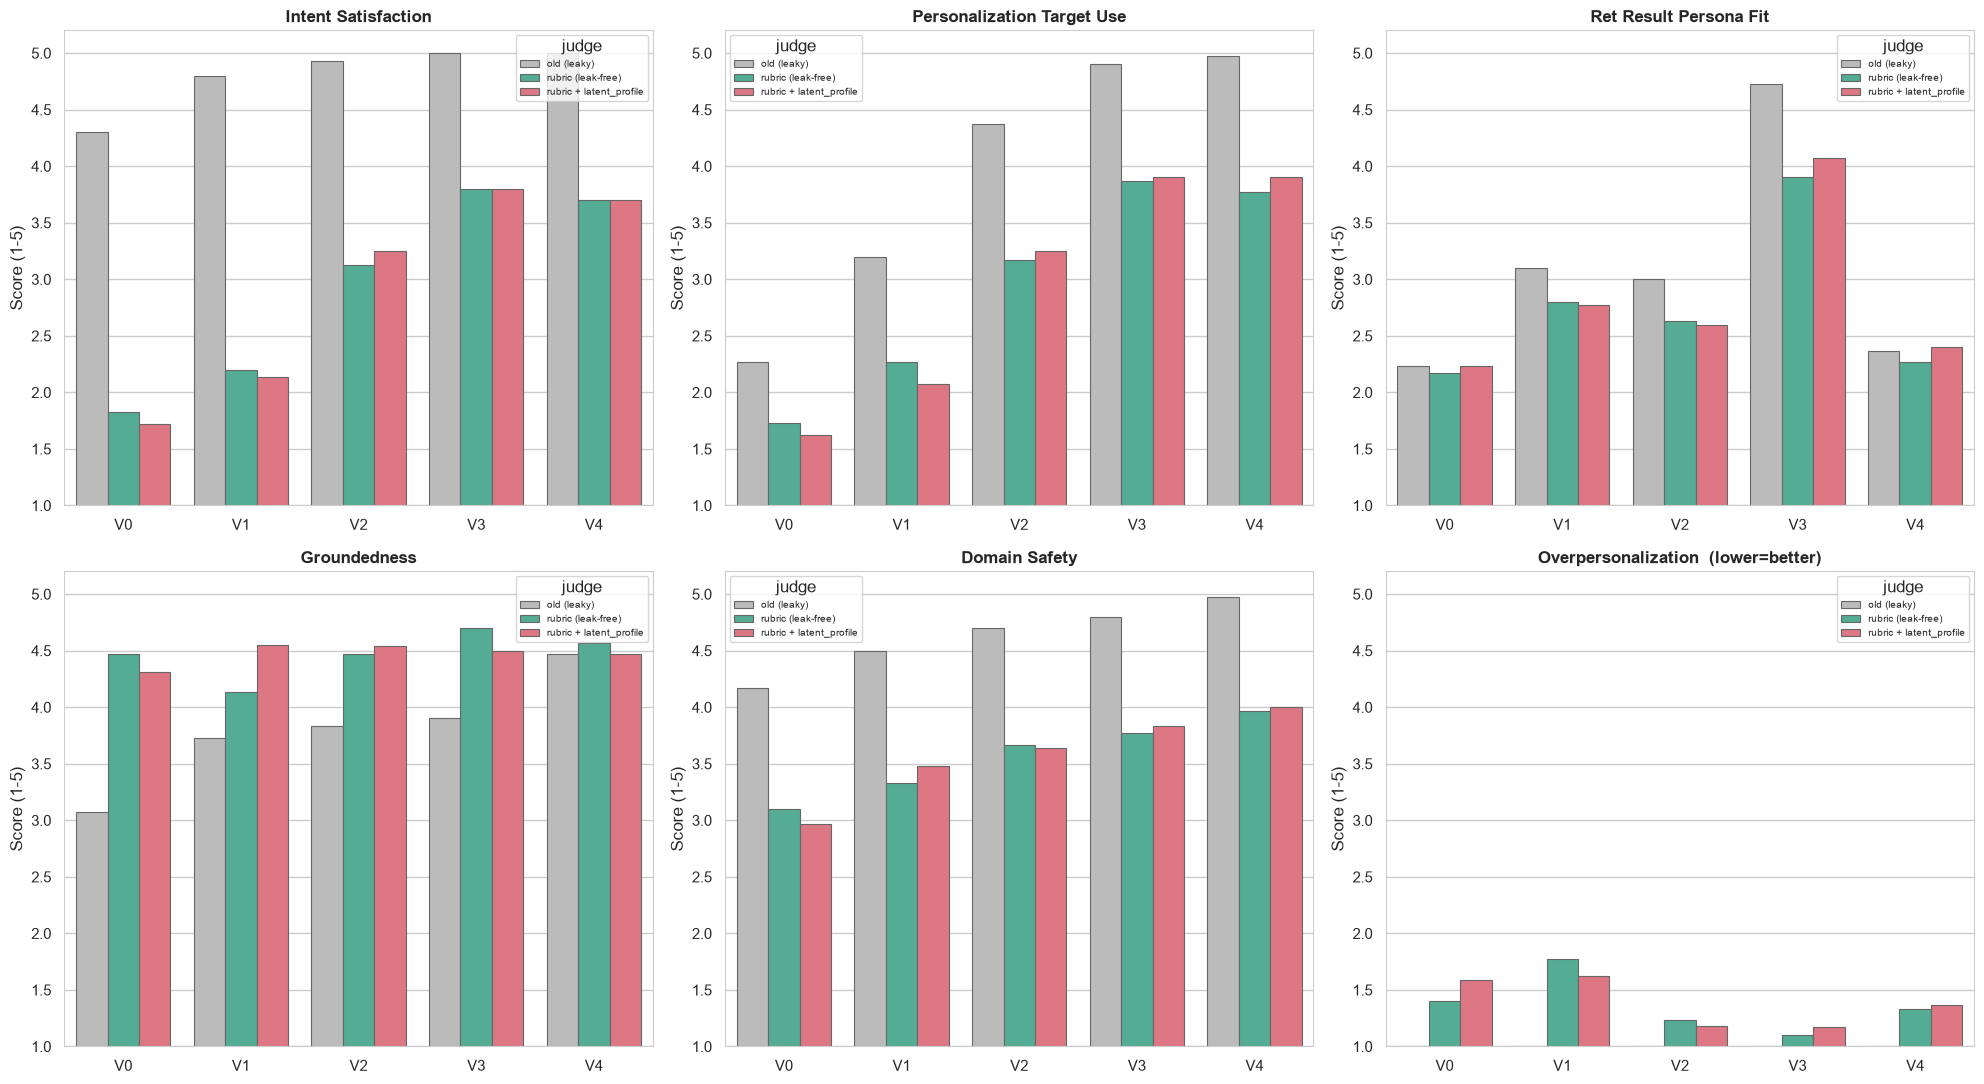

In [2]:
metrics = ["final_intent_satisfaction","final_personalization_target_use","retrieval_result_persona_fit",
           "final_groundedness","final_domain_safety","final_overpersonalization"]
cv = combined("variant")
fig, axes = plt.subplots(2, 3, figsize=(20, 11)); axes = axes.flatten()
for i, m in enumerate(metrics):
    col=f"{m}_mean"; ax=axes[i]
    if cv.empty or col not in cv.columns:
        ax.set_title(f"{m} (missing)"); ax.set_axis_off(); continue
    sns.barplot(data=cv, x="v", y=col, hue="condition", hue_order=COND_ORDER, order=SHORT,
                palette=COND_COLORS, edgecolor="#666", linewidth=0.8, ax=ax)
    ax.set_title(m.replace("final_","").replace("retrieval_","ret_").replace("_"," ").title()
                 + ("  (lower=better)" if "overpers" in m else ""), fontsize=12, fontweight="bold")
    ax.set_ylim(1, 5.2); ax.set_xlabel(""); ax.set_ylabel("Score (1-5)"); ax.legend(title="judge", fontsize=7)
plt.tight_layout(); plt.show()

## Section 2 — Task-type sensitivity & the groundedness check

Main's headline claim was a "force-personalization groundedness penalty" for V2 on retrieval tasks. Watch the
bottom-left panel: does V2 dip below V1 under the **leaky** judge but not under the **leak-free** one?

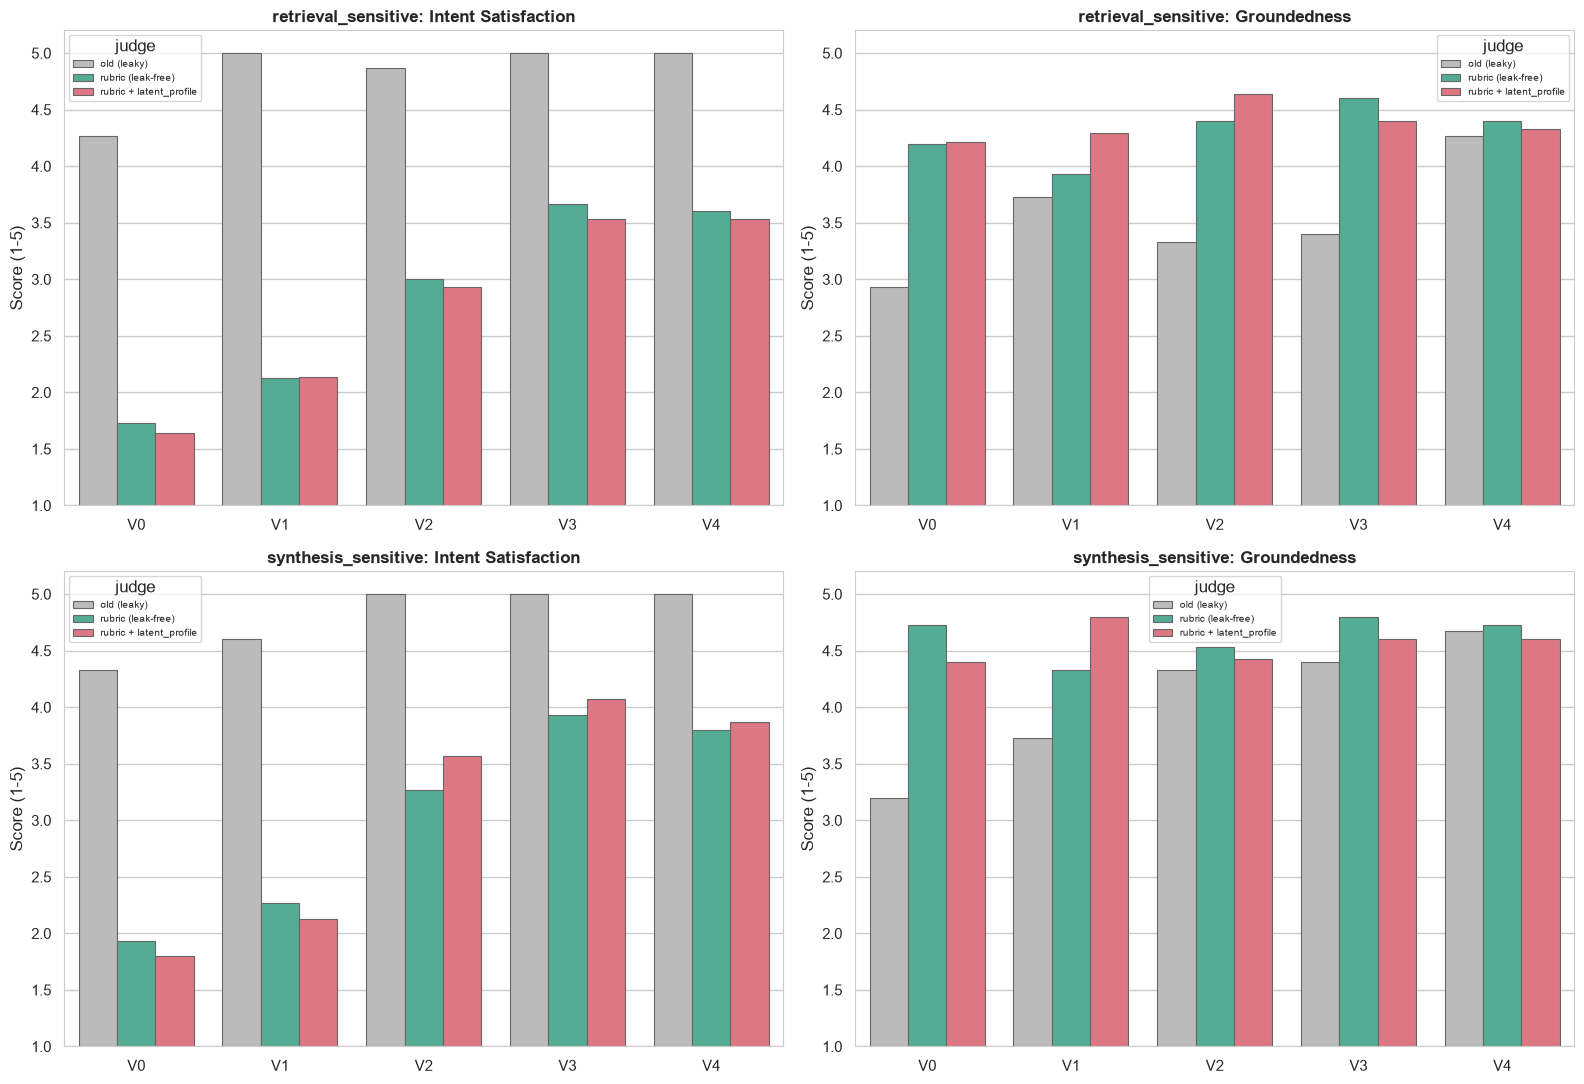

In [3]:
metrics = ["final_intent_satisfaction","final_groundedness"]
ctt = combined("variant_task_type")
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
for r, tt in enumerate(["retrieval_sensitive","synthesis_sensitive"]):
    sub = ctt[ctt["task_type"]==tt] if not ctt.empty else ctt
    for c, m in enumerate(metrics):
        col=f"{m}_mean"; ax=axes[r,c]
        if ctt.empty or col not in sub.columns: ax.set_title("missing"); ax.set_axis_off(); continue
        sns.barplot(data=sub, x="v", y=col, hue="condition", hue_order=COND_ORDER, order=SHORT,
                    palette=COND_COLORS, edgecolor="#666", linewidth=0.8, ax=ax)
        ax.set_title(f"{tt}: {m.replace('final_','').replace('_',' ').title()}", fontsize=12, fontweight="bold")
        ax.set_ylim(1, 5.2); ax.set_xlabel(""); ax.set_ylabel("Score (1-5)"); ax.legend(title="judge", fontsize=7)
plt.tight_layout(); plt.show()

### Note — why is `groundedness` flat across variants?

`groundedness` measures **faithfulness to the retrieved evidence** (did the answer stick to its sources, or hallucinate) — it is *not* a personalization metric. It is governed by the **synthesis prompt, which is identical for all five variants** and instructs the model to ground claims in the evidence and cite sources. The variants differ in *what evidence gets retrieved* (the fan-out) and *whether the persona is used at synthesis*, **not** in how disciplined the writing is about its sources — so groundedness is expected to be roughly flat (~4.5), while the personalization metrics (`intent_satisfaction`, `personalization_target_use`, `result_persona_fit`) do the separating.

This flatness is also the evidence against the *"force-personalization groundedness penalty."* The leaky judge manufactured a V2 dip by holding the persona answer key and scoring personalized-but-source-faithful answers as "ungrounded" (conflating *personalized beyond the visible evidence* with *unfaithful*). Grade against the rubric instead and the dip disappears (V2−V1 groundedness on retrieval flips from −0.40 to +0.47).

*Caveat:* flat-and-high may also reflect a near-ceiling metric and small n (~15 per cell), so treat `groundedness` as a safety/sanity axis ("personalization does not cause hallucination"), not a discriminating result.

## Section 3 — Statistical contrasts (effect sizes), all conditions

Deltas V2−V1 / V3−V2 / V3−V1 / V4−V3, one bar per judge condition. Where grey and green diverge, the leak
was distorting that conclusion. The **groundedness** panel is the decisive one for the "penalty" claim.

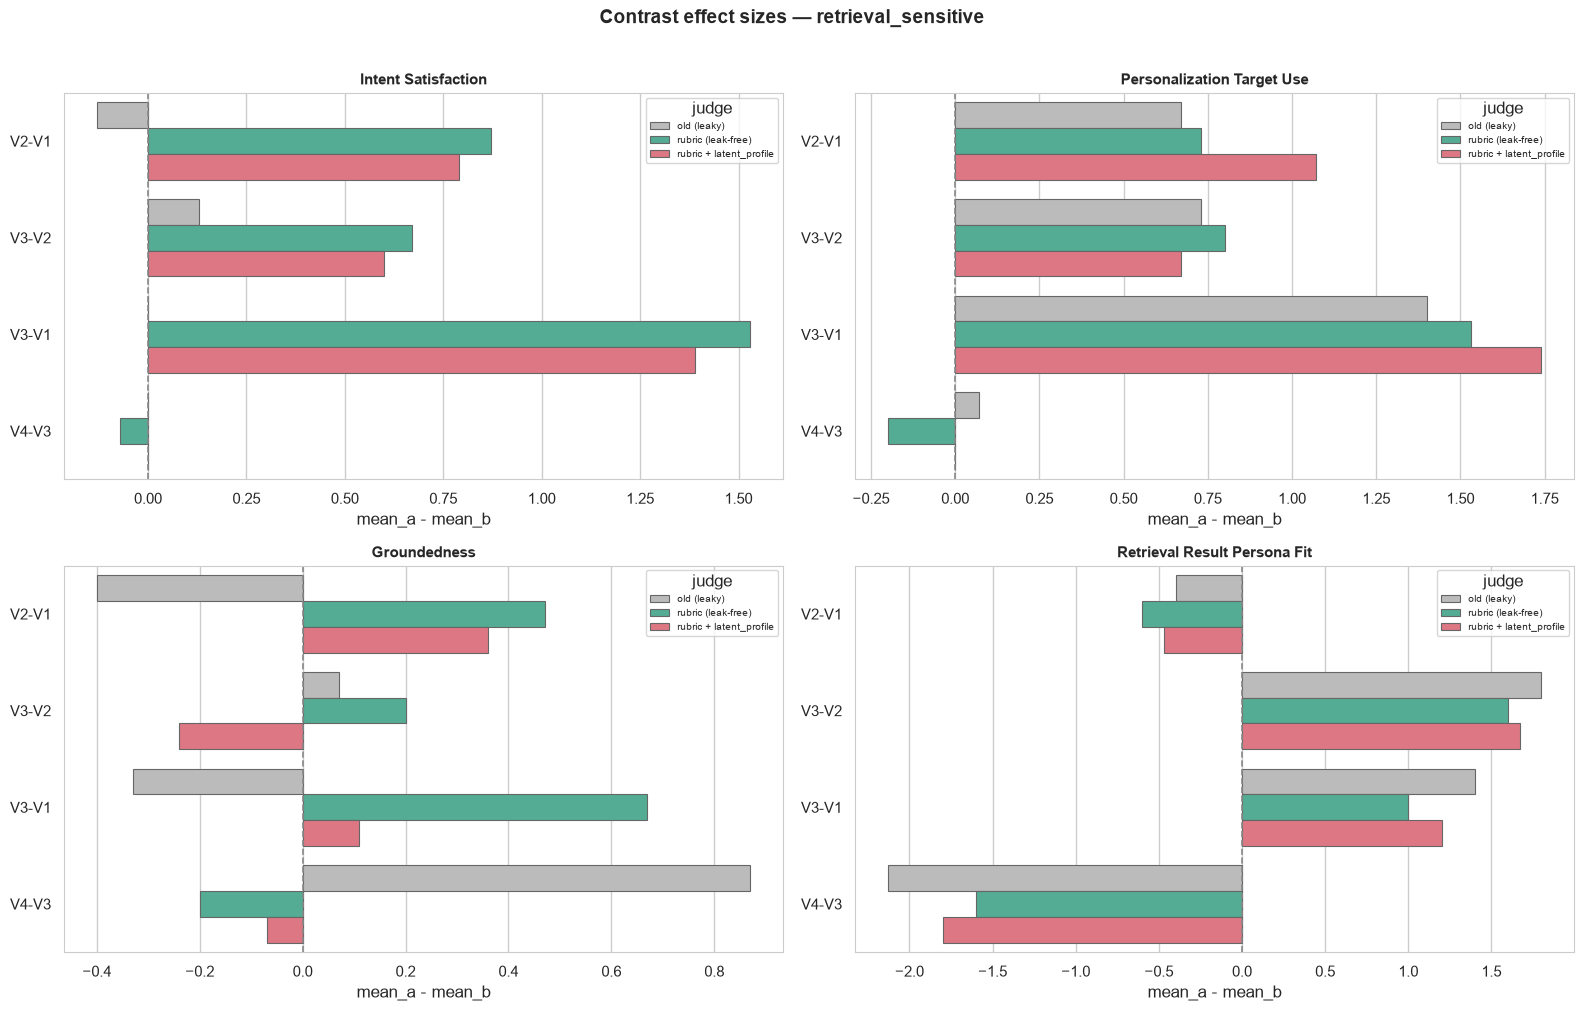

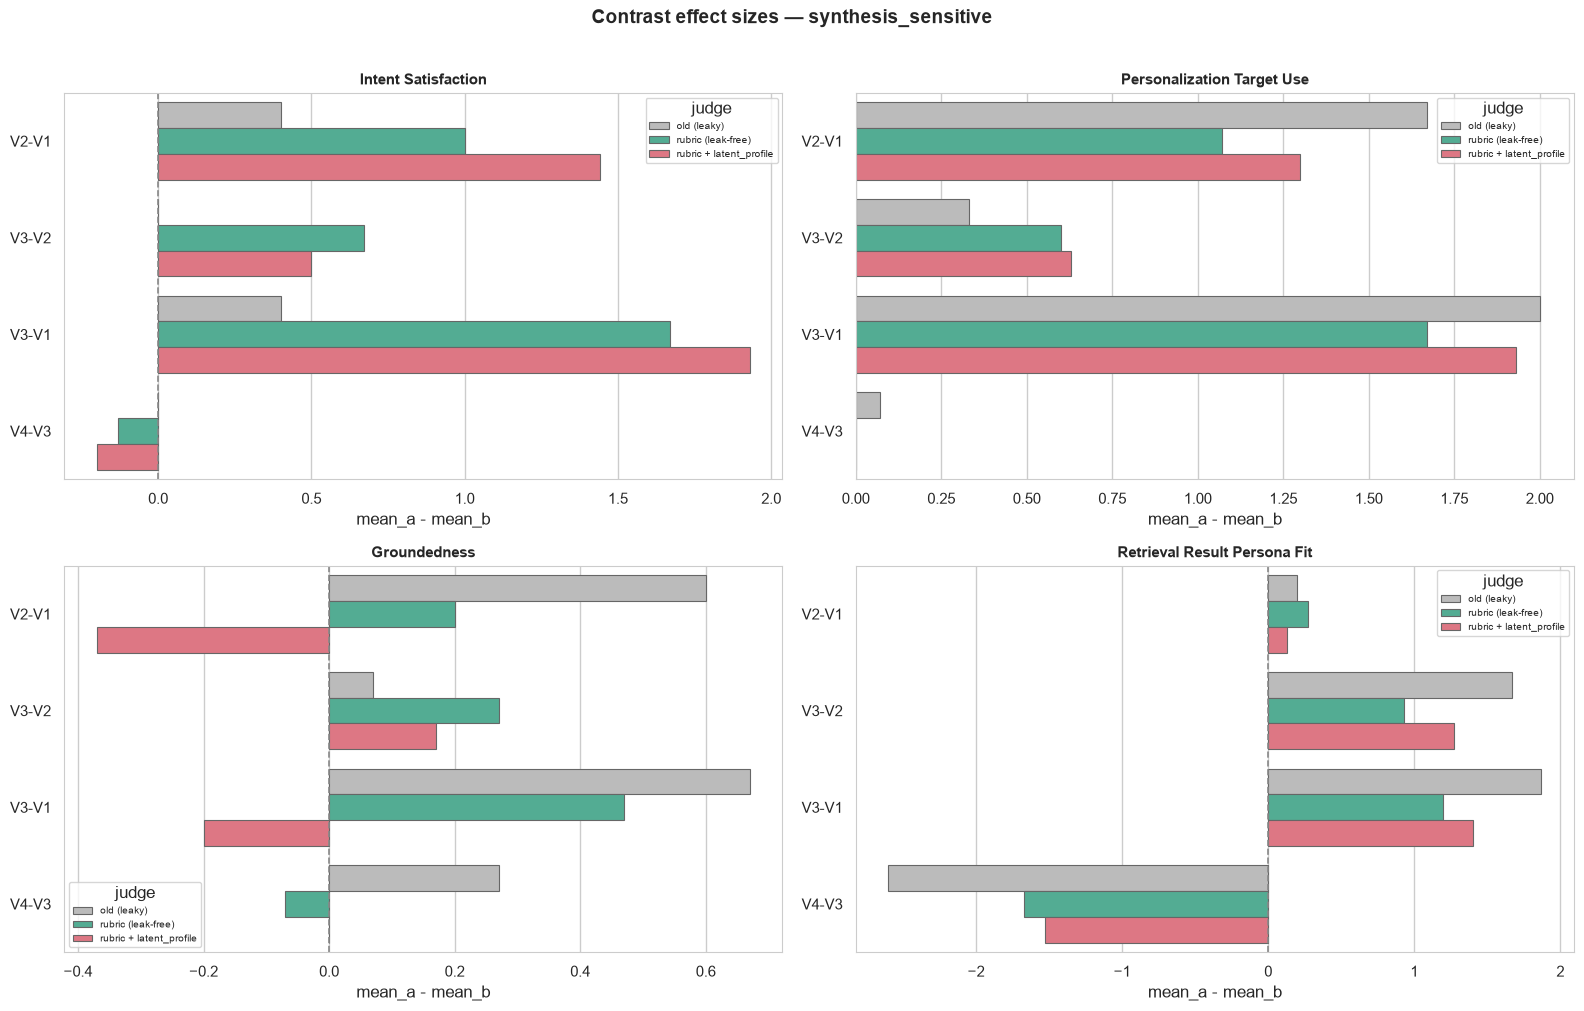

In [4]:
NAMES = {"synthesis personalization effect":"V2-V1",
         "marginal personalized fan-out effect given personalized synthesis":"V3-V2",
         "full personalization gain over generic fan-out":"V3-V1",
         "mixed/disconfirming fan-out effect":"V4-V3"}
SHORTC = ["V2-V1","V3-V2","V3-V1","V4-V3"]
focus = ["final_intent_satisfaction","final_personalization_target_use",
         "final_groundedness","retrieval_result_persona_fit"]
cc = combined("contrasts")
if not cc.empty: cc["contrast"] = cc["contrast_name"].map(NAMES)
for tt in ["retrieval_sensitive","synthesis_sensitive"]:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10)); axes = axes.flatten()
    fig.suptitle(f"Contrast effect sizes — {tt}", fontsize=14, fontweight="bold", y=1.01)
    for i, m in enumerate(focus):
        ax=axes[i]
        d = cc[(cc["metric"]==m)&(cc["task_type"]==tt)] if not cc.empty else cc
        if cc.empty or d.empty: ax.set_title(f"{m} (missing)"); ax.set_axis_off(); continue
        sns.barplot(data=d, y="contrast", x="diff_a_minus_b", hue="condition", hue_order=COND_ORDER, order=SHORTC,
                    palette=COND_COLORS, edgecolor="#666", linewidth=0.8, ax=ax)
        ax.axvline(0, color="#888", ls="--", lw=1.2)
        ax.set_title(m.replace("final_","").replace("_"," ").title(), fontsize=11, fontweight="bold")
        ax.set_xlabel("mean_a - mean_b"); ax.set_ylabel(""); ax.legend(title="judge", fontsize=7)
    plt.tight_layout(); plt.show()

### Contrast tables (numbers behind the bars)

In [5]:
def table(metric):
    cc = combined("contrasts")
    if cc.empty: return cc
    cc["contrast"] = cc["contrast_name"].map(NAMES)
    s = cc[cc["metric"]==metric]
    return s.pivot_table(index=["task_type","contrast"], columns="condition",
                         values="diff_a_minus_b", aggfunc="first").reindex(columns=COND_ORDER)
for m in ["final_intent_satisfaction","final_groundedness"]:
    print(f"\nΔ (mean_a - mean_b) for {m}:")
    try:
        from IPython.display import display; display(table(m).round(2))
    except Exception:
        print(table(m).round(2))


Δ (mean_a - mean_b) for final_intent_satisfaction:


condition                     old (leaky)  rubric (leak-free)  \
task_type           contrast                                    
retrieval_sensitive V2-V1           -0.13                0.87   
                    V3-V1            0.00                1.53   
                    V3-V2            0.13                0.67   
                    V4-V3            0.00               -0.07   
synthesis_sensitive V2-V1            0.40                1.00   
                    V3-V1            0.40                1.67   
                    V3-V2            0.00                0.67   
                    V4-V3            0.00               -0.13   

condition                     rubric + latent_profile  
task_type           contrast                           
retrieval_sensitive V2-V1                        0.79  
                    V3-V1                        1.39  
                    V3-V2                        0.60  
                    V4-V3                        0.00  
synthesis_sensitive V2-V1                        1.44  
                    V3-V1                        1.93  
                    V3-V2                        0.50  
                    V4-V3                       -0.20


Δ (mean_a - mean_b) for final_groundedness:


condition                     old (leaky)  rubric (leak-free)  \
task_type           contrast                                    
retrieval_sensitive V2-V1           -0.40                0.47   
                    V3-V1           -0.33                0.67   
                    V3-V2            0.07                0.20   
                    V4-V3            0.87               -0.20   
synthesis_sensitive V2-V1            0.60                0.20   
                    V3-V1            0.67                0.47   
                    V3-V2            0.07                0.27   
                    V4-V3            0.27               -0.07   

condition                     rubric + latent_profile  
task_type           contrast                           
retrieval_sensitive V2-V1                        0.36  
                    V3-V1                        0.11  
                    V3-V2                       -0.24  
                    V4-V3                       -0.07  
synthesis_sensitive V2-V1                       -0.37  
                    V3-V1                       -0.20  
                    V3-V2                        0.17  
                    V4-V3                        0.00

## Section 4 — Is the fix useful? (read-out)

Computed below, not hard-coded:

1. **Discrimination:** the leaky judge compresses every variant near the ceiling (tiny spread); the leak-free
   judge spreads them out, so the variant differences the study exists to measure become visible.
2. **The groundedness "penalty" reverses:** under the leaky judge V2−V1 groundedness on retrieval is negative
   (the penalty main reports); under the leak-free judge it is positive. The fix doesn't just rescale — it
   **flips the paper's headline conclusion**, so it is materially useful.
3. **The answer key is unnecessary:** green (rubric) ≈ red (rubric+profile), so the frozen rubric carries the
   signal and the leak-free judge is the one to report.

*Validity:* ~15 (persona × query) per task-type cell — directional, not powered; confirm at larger n.

In [6]:
cc = combined("contrasts")
if not cc.empty:
    cc["contrast"] = cc["contrast_name"].map(NAMES)
    print("1) Discrimination — intent_satisfaction spread across variants (bigger = more informative):")
    cv = combined("variant")
    for cond in COND_ORDER:
        s = cv[cv["condition"]==cond].set_index("variant")["final_intent_satisfaction_mean"]
        v0 = s.get("V0_generic_single", float("nan"))
        print(f"   {cond:26s} V0={v0:.2f}  spread(max-min)={s.max()-s.min():.2f}")
    print("\n2) V2-V1 groundedness on RETRIEVAL (negative = main's 'penalty'):")
    for cond in COND_ORDER:
        r = cc[(cc["condition"]==cond)&(cc["metric"]=="final_groundedness")&(cc["task_type"]=="retrieval_sensitive")&(cc["contrast"]=="V2-V1")]
        if len(r): print(f"   {cond:26s} {r['diff_a_minus_b'].iloc[0]:+.2f}")
    print("\n3) Answer key needed? largest |rubric - (rubric+profile)| across variant means:")
    cv = combined("variant"); cols=[c for c in cv.columns if c.endswith('_mean')]
    a = cv[cv['condition']=="rubric (leak-free)"].set_index('variant')[cols]
    b = cv[cv['condition']=="rubric + latent_profile"].set_index('variant')[cols]
    print(f"   {(a-b).abs().max().max():.2f}  (small => the leak-free rubric judge is sufficient)")

1) Discrimination — intent_satisfaction spread across variants (bigger = more informative):
   old (leaky)                V0=4.30  spread(max-min)=0.70
   rubric (leak-free)         V0=1.83  spread(max-min)=1.97
   rubric + latent_profile    V0=1.72  spread(max-min)=2.08

2) V2-V1 groundedness on RETRIEVAL (negative = main's 'penalty'):
   old (leaky)                -0.40
   rubric (leak-free)         +0.47
   rubric + latent_profile    +0.36

3) Answer key needed? largest |rubric - (rubric+profile)| across variant means:
   0.42  (small => the leak-free rubric judge is sufficient)
